In [1]:
from pathlib import Path
import numpy as np

PROCESSED_DIR = Path("../data/processed")

X_train = np.load(
    PROCESSED_DIR / "X_train_processed.npy"
)

X_test = np.load(
    PROCESSED_DIR / "X_test_processed.npy"
)

y_train = np.load(
    PROCESSED_DIR / "y_train.npy"
)

y_test = np.load(
    PROCESSED_DIR / "y_test.npy"
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5090096, 12)
X_test : (1272524, 12)
y_train: (5090096,)
y_test : (1272524,)


In [2]:
print("Training fraud distribution:")
print(np.unique(y_train, return_counts=True))

print("\nTest fraud distribution:")
print(np.unique(y_test, return_counts=True))

Training fraud distribution:
(array([0, 1]), array([5083526,    6570]))

Test fraud distribution:
(array([0, 1]), array([1270881,    1643]))


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

#### Logistic Regression

In [4]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [5]:
logistic_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [6]:
logistic_pred = logistic_model.predict(X_test)

logistic_proba = logistic_model.predict_proba(
    X_test
)[:, 1]

##### Create an evaluation function 
##### Instead of repeating the same code three times:

In [7]:
def evaluate_model(name, y_true, y_pred, y_proba):

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_proba
    )

    pr_auc = average_precision_score(
        y_true,
        y_proba
    )

    print(f"\n{name}")
    print("-" * 40)
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"PR-AUC    : {pr_auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "model": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

In [8]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_proba
)


Logistic Regression
----------------------------------------
Precision : 0.0252
Recall    : 0.9744
F1-score  : 0.0491
ROC-AUC   : 0.9946
PR-AUC    : 0.5923

Confusion Matrix:
[[1208917   61964]
 [     42    1601]]


#### Random Forest

Now train the second model.

Because you have 5 million training rows, don't start with hundreds of trees.

In [9]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

In [10]:
random_forest_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
rf_pred = random_forest_model.predict(X_test)

rf_proba = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [12]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_proba
)


Random Forest
----------------------------------------
Precision : 0.0933
Recall    : 0.9860
F1-score  : 0.1704
ROC-AUC   : 0.9992
PR-AUC    : 0.9046

Confusion Matrix:
[[1255131   15750]
 [     23    1620]]


#### XGBoost


In [13]:
from xgboost import XGBClassifier

In [14]:
negative_count = np.sum(y_train == 0)
positive_count = np.sum(y_train == 1)

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 773.7482496194825


In [15]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

In [16]:
xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [17]:
xgb_pred = xgb_model.predict(X_test)

xgb_proba = xgb_model.predict_proba(
    X_test
)[:, 1]

In [18]:
xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_proba
)


XGBoost
----------------------------------------
Precision : 0.2622
Recall    : 0.9951
F1-score  : 0.4150
ROC-AUC   : 0.9998
PR-AUC    : 0.9624

Confusion Matrix:
[[1266280    4601]
 [      8    1635]]


In [19]:
import pandas as pd

In [20]:
results = pd.DataFrame([
    logistic_results,
    rf_results,
    xgb_results
])

results

,model,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.025187,0.974437,0.049104,0.994626,0.592328
1,Random Forest,0.093264,0.986001,0.170410,0.999234,0.904647
2,XGBoost,0.262187,0.995131,0.415027,0.999834,0.962366


In [21]:
xgb_proba


array([2.9975332e-05, 1.9817277e-05, 6.2167528e-05, ..., 3.7373306e-06,
       4.7420007e-03, 7.4292853e-05], shape=(1272524,), dtype=float32)

In [22]:
print(xgb_proba[:10])
print(xgb_proba.min())
print(xgb_proba.max())

[2.9975332e-05 1.9817277e-05 6.2167528e-05 8.9624111e-05 3.9240016e-04
 1.1701069e-04 5.7982970e-02 2.8581370e-04 1.6596740e-04 5.6866147e-06]
3.373928e-07
0.99999166


In [23]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [24]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../artifacts/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "fraud_xgboost.pkl"

joblib.dump(xgb_model, MODEL_PATH)

print(f"Model saved successfully: {MODEL_PATH}")

Model saved successfully: ..\artifacts\models\fraud_xgboost.pkl


##### Threshold analysis

##### current prediction probably uses:

In [25]:
xgb_pred = xgb_model.predict(X_test)

In [26]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.10, 1.00, 0.05)

threshold_results = []

for threshold in thresholds:

    predictions = (
        xgb_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives
0,0.10,0.111496,0.998783,0.200599,1641,13077,2,1257804
1,0.15,0.133856,0.998174,0.236056,1640,10612,3,1260269
2,0.20,0.152729,0.998174,0.264922,1640,9098,3,1261783
3,0.25,0.170124,0.998174,0.290703,1640,8000,3,1262881
4,0.30,0.187829,0.997565,0.316135,1639,7087,4,1263794
5,0.35,0.205421,0.996348,0.340616,1637,6332,6,1264549
6,0.40,0.224602,0.995740,0.366529,1636,5648,7,1265233
7,0.45,0.242694,0.995740,0.390267,1636,5105,7,1265776
8,0.50,0.262187,0.995131,0.415027,1635,4601,8,1266280
9,0.55,0.281870,0.994522,0.439247,1634,4163,9,1266718


##### Understand what will happen

see something conceptually like:

Threshold ↓

    ↓
More transactions classified as fraud

    ↓
Recall tends to increase

    ↓
False positives tend to increase

    ↓
Precision can decrease

##### While increasing the threshold:

Threshold ↑

    ↓
Model becomes more conservative

    ↓
Fewer fraud alerts

    ↓
False positives tend to decrease

    ↓
But some fraud may be missed

This is the central threshold tradeoff.

##### Plot Precision vs Recall

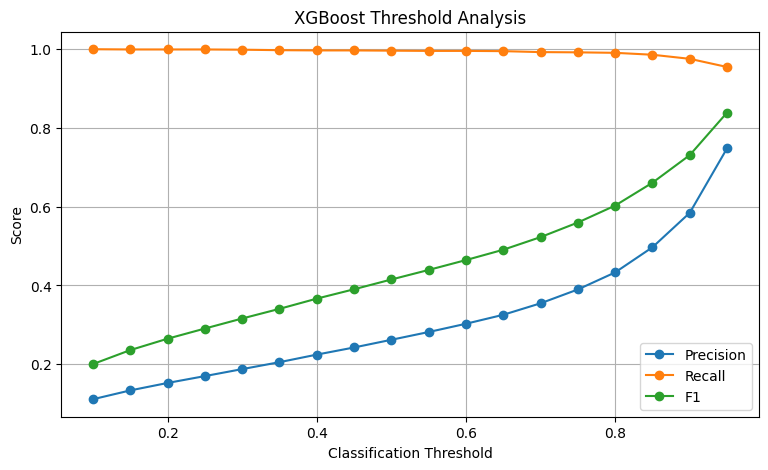

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Analysis")

plt.legend()
plt.grid(True)

plt.show()

##### Examine specific thresholds

In [28]:
selected_thresholds = threshold_df[
    threshold_df["threshold"].isin(
        [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    )
]

selected_thresholds

,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives
0,0.1,0.111496,0.998783,0.200599,1641,13077,2,1257804
2,0.2,0.152729,0.998174,0.264922,1640,9098,3,1261783
4,0.3,0.187829,0.997565,0.316135,1639,7087,4,1263794
6,0.4,0.224602,0.995740,0.366529,1636,5648,7,1265233
8,0.5,0.262187,0.995131,0.415027,1635,4601,8,1266280
10,0.6,0.302817,0.994522,0.464270,1634,3762,9,1267119
12,0.7,0.354670,0.991479,0.522450,1629,2964,14,1267917
14,0.8,0.433023,0.989653,0.602445,1626,2129,17,1268752
16,0.9,0.584093,0.974437,0.730383,1601,1140,42,1269741


Create the BankGuard risk score

Now create a function that converts probability into a risk level.

For example, using the configurable ranges in project plan:

Note:
These ranges are project configuration examples, not universal banking fraud thresholds. The project plan explicitly says the thresholds should remain configurable.

In [29]:
def get_risk_level(probability):

    if probability < 0.30:
        return "LOW"

    elif probability < 0.70:
        return "MEDIUM"

    else:
        return "HIGH"

##### Create BankGuard decisions

In [30]:
def get_decision(probability):

    if probability < 0.30:
        return "ALLOW"

    elif probability < 0.70:
        return "REVIEW"

    else:
        return "REVIEW"

##### Create a transaction risk example

In [31]:
def calculate_risk(probability):

    risk_level = get_risk_level(probability)
    decision = get_decision(probability)

    return {
        "fraud_probability": round(float(probability), 4),
        "risk_level": risk_level,
        "decision": decision
    }

In [32]:
calculate_risk(0.12)

{'fraud_probability': 0.12, 'risk_level': 'LOW', 'decision': 'ALLOW'}

In [33]:
print(calculate_risk(0.61))
print(calculate_risk(0.94))

{'fraud_probability': 0.61, 'risk_level': 'MEDIUM', 'decision': 'REVIEW'}
{'fraud_probability': 0.94, 'risk_level': 'HIGH', 'decision': 'REVIEW'}


Create actual test-set risk results

Let's attach the probabilities to the test transactions

In [34]:
risk_results = pd.DataFrame({
    "actual_fraud": y_test,
    "fraud_probability": xgb_proba
})

risk_results["risk_level"] = (
    risk_results["fraud_probability"]
    .apply(get_risk_level)
)

risk_results["decision"] = (
    risk_results["fraud_probability"]
    .apply(get_decision)
)

risk_results.head()

,actual_fraud,fraud_probability,risk_level,decision
0,0,0.000030,LOW,ALLOW
1,0,0.000020,LOW,ALLOW
2,0,0.000062,LOW,ALLOW
3,0,0.000090,LOW,ALLOW
4,0,0.000392,LOW,ALLOW


In [35]:
risk_results["risk_level"].value_counts()

risk_level
LOW       1263798
HIGH         4593
MEDIUM       4133
Name: count, dtype: int64

In [36]:
pd.crosstab(
    risk_results["risk_level"],
    risk_results["actual_fraud"],
    normalize="index"
).round(4)

actual_fraud,0,1
risk_level,,
HIGH,0.6453,0.3547
LOW,1.0000,0.0000
MEDIUM,0.9976,0.0024
